<a href="https://colab.research.google.com/github/jhenningsen/Equity_Analysis/blob/main/Leverage_ETFs/Log_Mean_Reversion_Discrete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TQQQ Trading Strategy Backtesting with Logarithmic Trend Mean Reversion

This notebook develops and backtests systematic trading strategies for TQQQ (ProShares UltraPro QQQ 3x Leveraged ETF) using a logarithmic trend mean reversion approach. The backtest period runs from TQQQ's inception date (February 11, 2010) to the present, utilizing adjusted prices from `yfinance`.

## Project Goals:
1.  **Develop Mean Reversion Strategies:** Implement and refine strategies that profit from TQQQ's tendency to revert to its long-term logarithmic trend.
2.  **Compare Performance:** Evaluate the strategies against a TQQQ Buy and Hold benchmark using key metrics like CAGR, Max Drawdown, Sharpe Ratio, and visual equity curves.

## Strategies:

### Discrete Residual Mean Reversion Strategy (Initial Approach)
*   **Core Concept:** This strategy aims to profit from the tendency of TQQQ's price to revert to its long-term logarithmic trend. It identifies overbought and oversold conditions based on residuals from a linear regression of TQQQ's log price over time.
*   **Mechanics:** Uses Gaussian Mixture Models (GMM) to cluster the residuals into different regimes (e.g., most oversold, moderately oversold, moderately overbought, most overbought). Allocations to TQQQ are then dynamically adjusted based on these discrete residual regimes, with higher allocations when TQQQ is oversold and lower/zero allocations when overbought.

## Benchmark: TQQQ Buy and Hold
*   **Core Concept:** A pure, passive buy-and-hold baseline to evaluate strategy outperformance (Alpha) and risk-adjusted return profiles.
*   **Mechanics:** Fully vectorized execution. 100% of capital is deployed into TQQQ on day one, compounding daily based on TQQQ's fractional percent changes.
*   **Historical Performance:** Historically (2010–2026), this benchmark compounds at a ~40% to 44% CAGR, but suffers an extreme maximum drawdown of ~81.6% during the 2022 market regime shift.

## Context Summary:
*   **Goal:** Evaluate a residual mean reversion strategy for TQQQ by using GMM to define residual regimes and associated asset allocations.
*   **Key Function:** The `run_discrete_gmm_strategy` function (cell `9c2d7968`) is used for all backtests. It accepts `n_components`, an `initial_portfolio_value`, and an optional `custom_allocation_map`. It returns the strategy DataFrame, a residual summary (including min, max, mean, count, and `Target_Allocation` for each regime), and performance metrics.
*   **Key Decisions/Refinements:**
    *   The `run_discrete_gmm_strategy` function was enhanced to accept a `custom_allocation_map` to allow for specific, non-linear allocations (e.g., for the original 4-component strategy).
    *   An `UnboundLocalError` in the function was fixed.
    *   The `Target_Allocation` percentage is now consistently included in the 'DISCOVERED RESIDUAL REGIMES' tables.

## Completed Analyses (Backtests, Metrics, Equity Curves, and Discussions):
*   **2-component strategy:** Achieved the highest CAGR (48.87%) and ending portfolio value, with simple allocations (1.0 for oversold, 0.0 for overbought), demonstrating strong capital appreciation. However, it also has a high maximum drawdown (-62.27%) and a Sharpe ratio (0.92) lower than some other strategies.
*   **3-component strategy:** Demonstrated excellent risk-adjusted returns (Sharpe 1.06) and a strong CAGR (43.29%), with default allocations (1.0, 0.5, 0.0).
*   **4-component strategy (Default Allocations):** Backtested with default allocations, it yielded a CAGR of 40.98%, Sharpe Ratio of 1.03, and Max Drawdown of -51.18%. This version, without a custom allocation map, still shows strong risk-adjusted returns.
*   **5-component strategy:** Backtested (CAGR 39.07%, Sharpe 1.02, Max Drawdown -50.89%).
*   **6-component strategy:** Backtested (CAGR 40.44%, Sharpe 1.01, Max Drawdown -51.14%).
*   **7-component strategy:** Backtested (CAGR 41.05%, Sharpe 0.99, Max Drawdown -52.38%).
*   **8-component strategy:** Backtested (CAGR 37.77%, Sharpe 0.99, Max Drawdown -49.26%).
*   **9-component strategy:** Backtested (CAGR 38.73%, Sharpe 0.98, Max Drawdown -50.42%) and equity curve plotted.
*   **10-component strategy:** Backtested (CAGR 37.13%, Sharpe 1.03, Max Drawdown -44.59%) and equity curve plotted.

## Unresolved Questions or Tasks:
*   The backtest, performance summary, and equity curve for the **11-component strategy** are still pending execution.
*   Further evaluation of the 2-component strategy to find its weak spots beyond just CAGR and ending portfolio value is requested.

In [1]:
# Import necessary libraries

import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display # Ensure display is available
from ipywidgets import interact, FloatSlider



In [2]:
# Clear all DataFrames from memory
import gc

# Get a list of all variables in the global namespace
all_vars = list(globals().keys())

# Identify and delete pandas DataFrames
for var_name in all_vars:
    if isinstance(globals()[var_name], pd.DataFrame):
        del globals()[var_name]
        print(f"Deleted DataFrame: {var_name}")

# Run garbage collector to free up memory
gc.collect()

print("All DataFrames cleared from memory.")

All DataFrames cleared from memory.


In [3]:
# Download TQQQ data
tickers = ["TQQQ"]
tqqq_data = yf.download(tickers, start="2010-02-11", end="2026-01-01", auto_adjust=True)['Close'].dropna()

# Convert to DataFrame if it's a Series (ensure tqqq_data is a DataFrame for subsequent operations)
if isinstance(tqqq_data, pd.Series):
    tqqq_data = tqqq_data.to_frame(name='TQQQ')

# Calculate TQQQ returns and create benchmark equity
tqqq_data['TQQQ_Return'] = tqqq_data['TQQQ'].pct_change()

# Create a copy for regression analysis and to serve as the consistent base for all strategies
regression_df = tqqq_data.copy()

# Calculate Standard_Benchmark_Equity once here to be used across all strategies
initial_portfolio_value_benchmark = 100000.0
# Use fillna(1) for the first return to correctly initialize cumprod for the benchmark
regression_df['Standard_Benchmark_Equity'] = (1 + regression_df['TQQQ_Return']).fillna(1).cumprod() * initial_portfolio_value_benchmark

print("TQQQ data and Benchmark Equity prepared.")

# Calculate TQQQ log price, trend line, and residuals
regression_df['TQQQ_Log_Price'] = np.log(regression_df['TQQQ'])
regression_df['Days_Since_Start'] = np.arange(len(regression_df))
X = regression_df[['Days_Since_Start']]
y = regression_df['TQQQ_Log_Price']
model = LinearRegression()
model.fit(X, y)
regression_df['TQQQ_Trend_Line'] = model.predict(X)
regression_df['TQQQ_Residuals'] = regression_df['TQQQ_Log_Price'] - regression_df['TQQQ_Trend_Line']

print("TQQQ Log Price, Trend Line, and Residuals calculated and added to regression_df for plotting.")

[*********************100%***********************]  1 of 1 completed

TQQQ data and Benchmark Equity prepared.
TQQQ Log Price, Trend Line, and Residuals calculated and added to regression_df for plotting.


Now, let's visualize the log price, the linear regression trend line, and the residuals. This will help us understand the deviations from the trend.

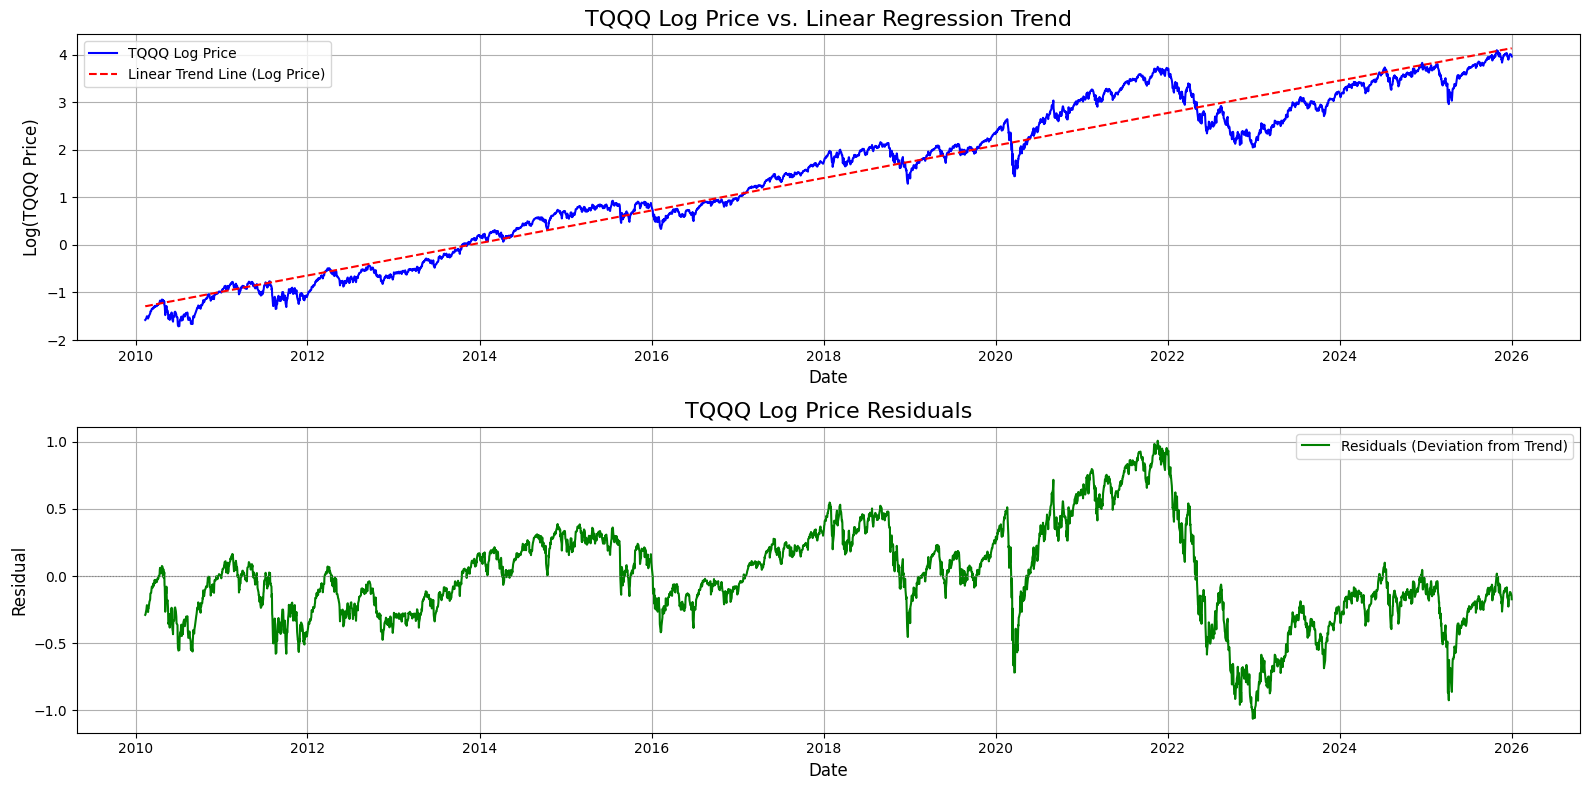

In [4]:
# Plot TQQQ log price, trend, and residuals
plt.figure(figsize=(16, 8))

# Plot Log Price and Trend Line
plt.subplot(2, 1, 1) # 2 rows, 1 column, first plot
plt.plot(regression_df.index, regression_df['TQQQ_Log_Price'], label='TQQQ Log Price', color='blue')
plt.plot(regression_df.index, regression_df['TQQQ_Trend_Line'], label='Linear Trend Line (Log Price)', color='red', linestyle='--')
plt.title('TQQQ Log Price vs. Linear Regression Trend', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Log(TQQQ Price)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)

# Plot Residuals
plt.subplot(2, 1, 2) # 2 rows, 1 column, second plot
plt.plot(regression_df.index, regression_df['TQQQ_Residuals'], label='Residuals (Deviation from Trend)', color='green')
plt.axhline(0, color='gray', linestyle=':', linewidth=0.8)
plt.title('TQQQ Log Price Residuals', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Residual', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)

plt.tight_layout()
plt.show()

The residuals represent how far TQQQ's log price is from its calculated long-term linear trend. A mean reversion strategy would typically involve:

1.  **Going Long (Buying TQQQ):** When the residuals fall significantly below zero, indicating TQQQ is oversold relative to its trend.
2.  **Going Short (Selling TQQQ):** When the residuals rise significantly above zero, indicating TQQQ is overbought relative to its trend.

You would need to define thresholds (e.g., standard deviations of residuals) to trigger these buy/sell signals.

## Mean Reversion Strategy Implementation

In [13]:
def run_discrete_gmm_strategy(base_regression_df, n_components, initial_portfolio_value, custom_allocation_map=None):
    """
    Runs a discrete GMM-based mean reversion strategy for a given number of components.

    Args:
        base_regression_df (pd.DataFrame): The DataFrame containing TQQQ data, log prices,
                                            trend lines, residuals, and benchmark equity.
        n_components (int): The number of Gaussian Mixture Model components (regimes).
        initial_portfolio_value (float): The starting portfolio value for the backtest.
        custom_allocation_map (dict, optional): A dictionary defining specific allocations
                                                for each residual regime. If None, allocations
                                                are dynamically calculated as 1.0 - (i / (n_components - 1)).

    Returns:
        dict: A dictionary containing the strategy DataFrame, performance metrics, and residual summary.
    """
    regression_df = base_regression_df.copy() # Work on a copy to avoid modifying original

    # GMM for n_components
    X_residuals = regression_df['TQQQ_Residuals'].values.reshape(-1, 1)
    gmm_residuals = GaussianMixture(n_components=n_components, random_state=42, covariance_type='full')
    raw_labels_residuals = gmm_residuals.fit_predict(X_residuals)
    idx_residuals = np.argsort(gmm_residuals.means_.flatten())
    state_map_residuals = {old_label: new_label for new_label, old_label in enumerate(idx_residuals)}
    regression_df['Residual_Regime'] = [state_map_residuals[label] for label in raw_labels_residuals]

    # Dynamically define allocation_map based on n_components, or use custom_allocation_map if provided
    if custom_allocation_map:
        allocation_map = custom_allocation_map
    else:
        # Allocations range from 1.0 (most oversold) to 0.0 (most overbought)
        allocation_map = {i: 1.0 - (i / (n_components - 1)) if n_components > 1 else 1.0 for i in range(n_components)}

    regression_df['Target_Allocation'] = regression_df['Residual_Regime'].map(allocation_map)

    # Generate and display the summary of discovered residual regimes
    residual_summary = regression_df.groupby('Residual_Regime')['TQQQ_Residuals'].agg(['min', 'max', 'mean', 'count'])
    # Add Target_Allocation to the residual_summary
    allocation_series = pd.Series(allocation_map, name='Target_Allocation')
    residual_summary = residual_summary.merge(allocation_series.to_frame(), left_index=True, right_index=True)

    # Backtest and create strategy_df
    strategy_df = regression_df[['TQQQ', 'TQQQ_Return', 'Target_Allocation', 'Standard_Benchmark_Equity']].copy()
    strategy_df['TQQQ_Daily_Return'] = strategy_df['TQQQ_Return']
    strategy_df = strategy_df.dropna()
    strategy_df['Allocated_Weight'] = strategy_df['Target_Allocation'].shift(1)
    strategy_df = strategy_df.dropna()
    strategy_df['Strategy_Daily_Return'] = strategy_df['Allocated_Weight'] * strategy_df['TQQQ_Daily_Return']

    strategy_df['Strategy_Equity'] = (1 + strategy_df['Strategy_Daily_Return']).cumprod() * initial_portfolio_value
    strategy_df['Benchmark_Equity'] = strategy_df['Standard_Benchmark_Equity'].reindex(strategy_df.index)

    # Metrics calculation function
    def calculate_metrics(return_series, equity_series, initial_value):
        if len(equity_series) == 0 or initial_value == 0:
            return 0.0, 0.0, 0.0, 0.0

        total_return = (equity_series.iloc[-1] / initial_value - 1)
        # Ensure we have enough data points for annualization
        if len(equity_series) < 252:
            years = len(equity_series) / 252.0 if len(equity_series) > 0 else 1.0
        else:
            years = (equity_series.index[-1] - equity_series.index[0]).days / 365.25

        cagr = ((equity_series.iloc[-1] / initial_value) ** (1 / years) - 1) * 100 if years > 0 else 0.0
        ann_vol = return_series.std() * np.sqrt(252) * 100
        sharpe = cagr / ann_vol if ann_vol != 0 else 0.0

        rolling_max = equity_series.cummax()
        drawdowns = (equity_series - rolling_max) / rolling_max
        max_dd = drawdowns.min() * 100
        return cagr, ann_vol, sharpe, max_dd

    strat_cagr, strat_vol, strat_sharpe, strat_mdd = calculate_metrics(
        strategy_df['Strategy_Daily_Return'], strategy_df['Strategy_Equity'], initial_portfolio_value)
    bench_cagr, bench_vol, bench_sharpe, bench_mdd = calculate_metrics(
        strategy_df['TQQQ_Daily_Return'], strategy_df['Benchmark_Equity'], initial_portfolio_value)

    final_strat_equity = strategy_df['Strategy_Equity'].iloc[-1]
    final_bench_equity = strategy_df['Benchmark_Equity'].iloc[-1]

    val_strat_str = f"${final_strat_equity:,.2f}"
    val_bench_str = f"${final_bench_equity:,.2f}"
    cagr_strat_str = f"{strat_cagr:.2f}%"
    cagr_bench_str = f"{bench_cagr:.2f}%"
    mdd_strat_str = f"{strat_mdd:.2f}%"
    mdd_bench_str = f"{bench_mdd:.2f}%"

    results = {
        'strategy_df': strategy_df,
        'residual_summary': residual_summary,
        'strat_cagr': strat_cagr, 'strat_vol': strat_vol, 'strat_sharpe': strat_sharpe, 'strat_mdd': strat_mdd,
        'bench_cagr': bench_cagr, 'bench_vol': bench_vol, 'bench_sharpe': bench_sharpe, 'bench_mdd': bench_mdd,
        'val_strat_str': val_strat_str, 'val_bench_str': val_bench_str,
        'cagr_strat_str': cagr_strat_str, 'cagr_bench_str': cagr_bench_str,
        'mdd_strat_str': mdd_strat_str, 'mdd_bench_str': mdd_bench_str
    }
    return results

### Mean Reversion Strategy based on Logarithmic Trend - 2 Residuals

### Backtesting the 2 Discrete Residual Mean Reversion Strategy

In [26]:
# Run the discrete GMM strategy for 2 components
initial_portfolio_value = 100000.0
gmm_2_component_results = run_discrete_gmm_strategy(regression_df, n_components=2, initial_portfolio_value=initial_portfolio_value)

# Extract results for printing
strategy_df_2_comp = gmm_2_component_results['strategy_df'] # Use a different name to avoid conflict
residual_summary_2_comp = gmm_2_component_results['residual_summary']
val_strat_str_2_comp = gmm_2_component_results['val_strat_str']
val_bench_str_2_comp = gmm_2_component_results['val_bench_str']
cagr_strat_str_2_comp = gmm_2_component_results['cagr_strat_str']
cagr_bench_str_2_comp = gmm_2_component_results['cagr_bench_str']
strat_vol_2_comp = gmm_2_component_results['strat_vol']
bench_vol_2_comp = gmm_2_component_results['bench_vol']
strat_sharpe_2_comp = gmm_2_component_results['strat_sharpe']
bench_sharpe_2_comp = gmm_2_component_results['bench_sharpe']
mdd_strat_str_2_comp = gmm_2_component_results['mdd_strat_str']
mdd_bench_str_2_comp = gmm_2_component_results['mdd_bench_str']

print("\n--- DISCOVERED RESIDUAL REGIMES (2 Components) ---")
display(residual_summary_2_comp)
print(f"\n--- 2-COMPONENT GMM STRATEGY PERFORMANCE ---")
print(f"\n{'Metric':<25}{'Residual Mean Reversion':<25}{'TQQQ Buy & Hold':<20}")
print("-" * 70)
print(f"{'Ending Portfolio Value':<25}{val_strat_str_2_comp:<25}{val_bench_str_2_comp:<20}")
print(f"{'CAGR':<25}{cagr_strat_str_2_comp:<25}{cagr_bench_str_2_comp:<20}")
print(f"{'Annualized Vol':<25}{f'{strat_vol_2_comp:.2f}%':<25}{f'{bench_vol_2_comp:.2f}%':<20}")
print(f"{'Sharpe Ratio':<25}{f'{strat_sharpe_2_comp:.2f}':<25}{f'{bench_sharpe_2_comp:.2f}':<20}")
print(f"{'Max Drawdown':<25}{mdd_strat_str_2_comp:<25}{mdd_bench_str_2_comp:<20}")
print("-" * 70)


--- DISCOVERED RESIDUAL REGIMES (2 Components) ---


,min,max,mean,count,Target_Allocation
Residual_Regime,,,,,
0,-1.063691,0.190637,-0.171720,2862,1.0
1,0.190707,1.008557,0.433006,1135,0.0



--- 2-COMPONENT GMM STRATEGY PERFORMANCE ---

Metric                   Residual Mean Reversion  TQQQ Buy & Hold     
----------------------------------------------------------------------
Ending Portfolio Value   $55,315,336.20           $25,543,135.53      
CAGR                     48.87%                   41.80%              
Annualized Vol           53.31%                   61.11%              
Sharpe Ratio             0.92                     0.68                
Max Drawdown             -62.27%                  -81.66%             
----------------------------------------------------------------------


### 2 Discrete Residual Mean Reversion Strategy Equity Curve

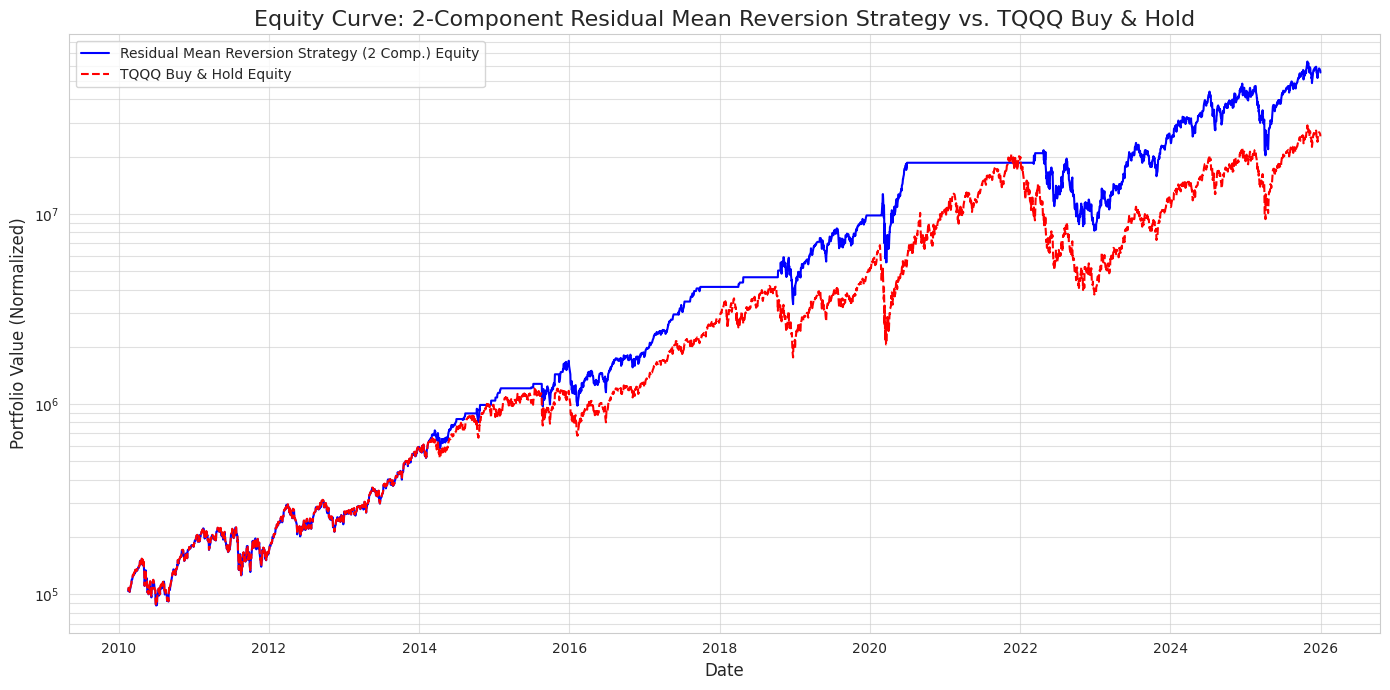

In [27]:
sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))

plt.plot(strategy_df_2_comp.index, strategy_df_2_comp['Strategy_Equity'], label='Residual Mean Reversion Strategy (2 Comp.) Equity', color='blue')
plt.plot(strategy_df_2_comp.index, strategy_df_2_comp['Benchmark_Equity'], label='TQQQ Buy & Hold Equity', color='red', linestyle='--')

plt.title('Equity Curve: 2-Component Residual Mean Reversion Strategy vs. TQQQ Buy & Hold', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value (Normalized)', fontsize=12)
plt.legend(fontsize=10)
plt.yscale('log') # Use log scale for better visualization of exponential growth
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

### Mean Reversion Strategy based on Logarithmic Trend - 3 Residuals

### Backtesting the 3 Discrete Residual Mean Reversion Strategy

In [24]:
# Run the discrete GMM strategy for 3 components
initial_portfolio_value = 100000.0
gmm_3_component_results = run_discrete_gmm_strategy(regression_df, n_components=3, initial_portfolio_value=initial_portfolio_value)

# Extract results for printing
strategy_df_3_comp = gmm_3_component_results['strategy_df'] # Use a different name to avoid conflict
residual_summary_3_comp = gmm_3_component_results['residual_summary']
val_strat_str_3_comp = gmm_3_component_results['val_strat_str']
val_bench_str_3_comp = gmm_3_component_results['val_bench_str']
cagr_strat_str_3_comp = gmm_3_component_results['cagr_strat_str']
cagr_bench_str_3_comp = gmm_3_component_results['cagr_bench_str']
strat_vol_3_comp = gmm_3_component_results['strat_vol']
bench_vol_3_comp = gmm_3_component_results['bench_vol']
strat_sharpe_3_comp = gmm_3_component_results['strat_sharpe']
bench_sharpe_3_comp = gmm_3_component_results['bench_sharpe']
mdd_strat_str_3_comp = gmm_3_component_results['mdd_strat_str']
mdd_bench_str_3_comp = gmm_3_component_results['mdd_bench_str']

print("\n--- DISCOVERED RESIDUAL REGIMES (3 Components) ---")
display(residual_summary_3_comp)
print(f"\n--- 3-COMPONENT GMM STRATEGY PERFORMANCE ---")
print(f"\n{'Metric':<25}{'Residual Mean Reversion':<25}{'TQQQ Buy & Hold':<20}")
print("-" * 70)
print(f"{'Ending Portfolio Value':<25}{val_strat_str_3_comp:<25}{val_bench_str_3_comp:<20}")
print(f"{'CAGR':<25}{cagr_strat_str_3_comp:<25}{cagr_bench_str_3_comp:<20}")
print(f"{'Annualized Vol':<25}{f'{strat_vol_3_comp:.2f}%':<25}{f'{bench_vol_3_comp:.2f}%':<20}")
print(f"{'Sharpe Ratio':<25}{f'{strat_sharpe_3_comp:.2f}':<25}{f'{bench_sharpe_3_comp:.2f}':<20}")
print(f"{'Max Drawdown':<25}{mdd_strat_str_3_comp:<25}{mdd_bench_str_3_comp:<20}")
print("-" * 70)


--- DISCOVERED RESIDUAL REGIMES (3 Components) ---


,min,max,mean,count,Target_Allocation
Residual_Regime,,,,,
0,-1.063691,-0.306072,-0.498180,692,1.0
1,-0.305838,0.308433,-0.017113,2587,0.5
2,0.308495,1.008557,0.541799,718,0.0



--- 3-COMPONENT GMM STRATEGY PERFORMANCE ---

Metric                   Residual Mean Reversion  TQQQ Buy & Hold     
----------------------------------------------------------------------
Ending Portfolio Value   $30,164,805.65           $25,543,135.53      
CAGR                     43.29%                   41.80%              
Annualized Vol           40.86%                   61.11%              
Sharpe Ratio             1.06                     0.68                
Max Drawdown             -52.45%                  -81.66%             
----------------------------------------------------------------------


### 3 Discrete Residual Mean Reversion Strategy Equity Curve

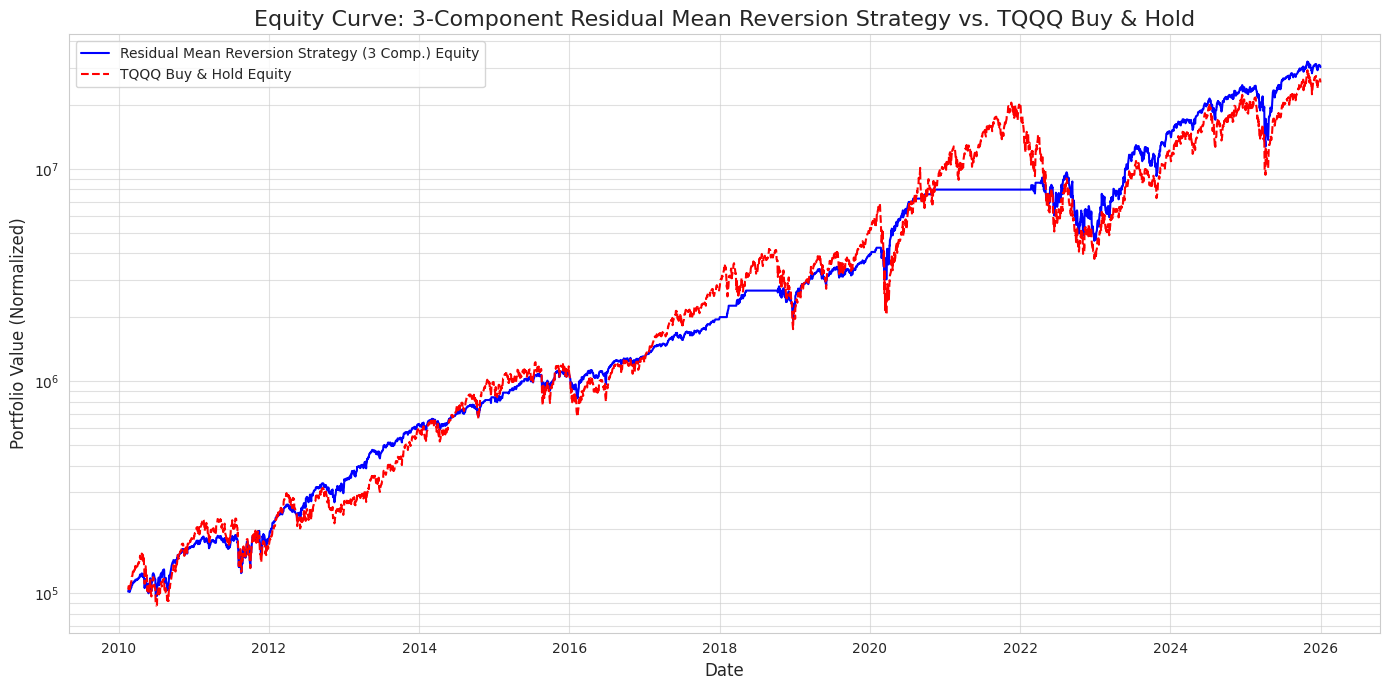

In [25]:
sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))

plt.plot(strategy_df_3_comp.index, strategy_df_3_comp['Strategy_Equity'], label='Residual Mean Reversion Strategy (3 Comp.) Equity', color='blue')
plt.plot(strategy_df_3_comp.index, strategy_df_3_comp['Benchmark_Equity'], label='TQQQ Buy & Hold Equity', color='red', linestyle='--')

plt.title('Equity Curve: 3-Component Residual Mean Reversion Strategy vs. TQQQ Buy & Hold', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value (Normalized)', fontsize=12)
plt.legend(fontsize=10)
plt.yscale('log') # Use log scale for better visualization of exponential growth
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

### Mean Reversion Strategy based on Logarithmic Trend - 4 Residuals

### Backtesting the 4 Discrete Residual Mean Reversion Strategy

In [38]:
# Run the discrete GMM strategy for 4 components using default allocations
initial_portfolio_value = 100000.0
gmm_4_component_results = run_discrete_gmm_strategy(
    regression_df,
    n_components=4,
    initial_portfolio_value=initial_portfolio_value
)

# Extract results for printing
strategy_df = gmm_4_component_results['strategy_df'] # Assign to strategy_df to maintain consistency with plot cell
residual_summary_4_comp = gmm_4_component_results['residual_summary']
val_strat_str = gmm_4_component_results['val_strat_str']
val_bench_str = gmm_4_component_results['val_bench_str']
cagr_strat_str = gmm_4_component_results['cagr_strat_str']
cagr_bench_str = gmm_4_component_results['cagr_bench_str']
strat_vol = gmm_4_component_results['strat_vol']
bench_vol = gmm_4_component_results['bench_vol']
strat_sharpe = gmm_4_component_results['strat_sharpe']
bench_sharpe = gmm_4_component_results['bench_sharpe']
mdd_strat_str = gmm_4_component_results['mdd_strat_str']
mdd_bench_str = gmm_4_component_results['mdd_bench_str']

print("\n--- DISCOVERED RESIDUAL REGIMES (4 Components - Default Allocations) ---")
display(residual_summary_4_comp)
print(f"\n--- 4-COMPONENT GMM STRATEGY PERFORMANCE (Default Allocations) ---")
print(f"\n{'Metric':<25}{'Residual Mean Reversion':<25}{'TQQQ Buy & Hold':<20}")
print("-" * 70)
print(f"{'Ending Portfolio Value':<25}{val_strat_str:<25}{val_bench_str:<20}")
print(f"{'CAGR':<25}{cagr_strat_str:<25}{cagr_bench_str:<20}")
print(f"{'Annualized Vol':<25}{f'{strat_vol:.2f}%':<25}{f'{bench_vol:.2f}%':<20}")
print(f"{'Sharpe Ratio':<25}{f'{strat_sharpe:.2f}':<25}{f'{bench_sharpe:.2f}':<20}")
print(f"{'Max Drawdown':<25}{mdd_strat_str:<25}{mdd_bench_str:<20}")
print("-" * 70)


--- DISCOVERED RESIDUAL REGIMES (4 Components - Default Allocations) ---


,min,max,mean,count,Target_Allocation
Residual_Regime,,,,,
0,-1.063691,-0.453206,-0.655360,316,1.000000
1,-0.451638,0.024853,-0.179508,1941,0.666667
2,0.025514,0.455915,0.213830,1346,0.333333
3,0.456364,1.008557,0.679451,394,0.000000



--- 4-COMPONENT GMM STRATEGY PERFORMANCE (Default Allocations) ---

Metric                   Residual Mean Reversion  TQQQ Buy & Hold     
----------------------------------------------------------------------
Ending Portfolio Value   $23,296,420.93           $25,543,135.53      
CAGR                     40.98%                   41.80%              
Annualized Vol           39.95%                   61.11%              
Sharpe Ratio             1.03                     0.68                
Max Drawdown             -51.18%                  -81.66%             
----------------------------------------------------------------------


### 4 Discrete Residual Mean Reversion Strategy Equity Curve (Default Allocations)

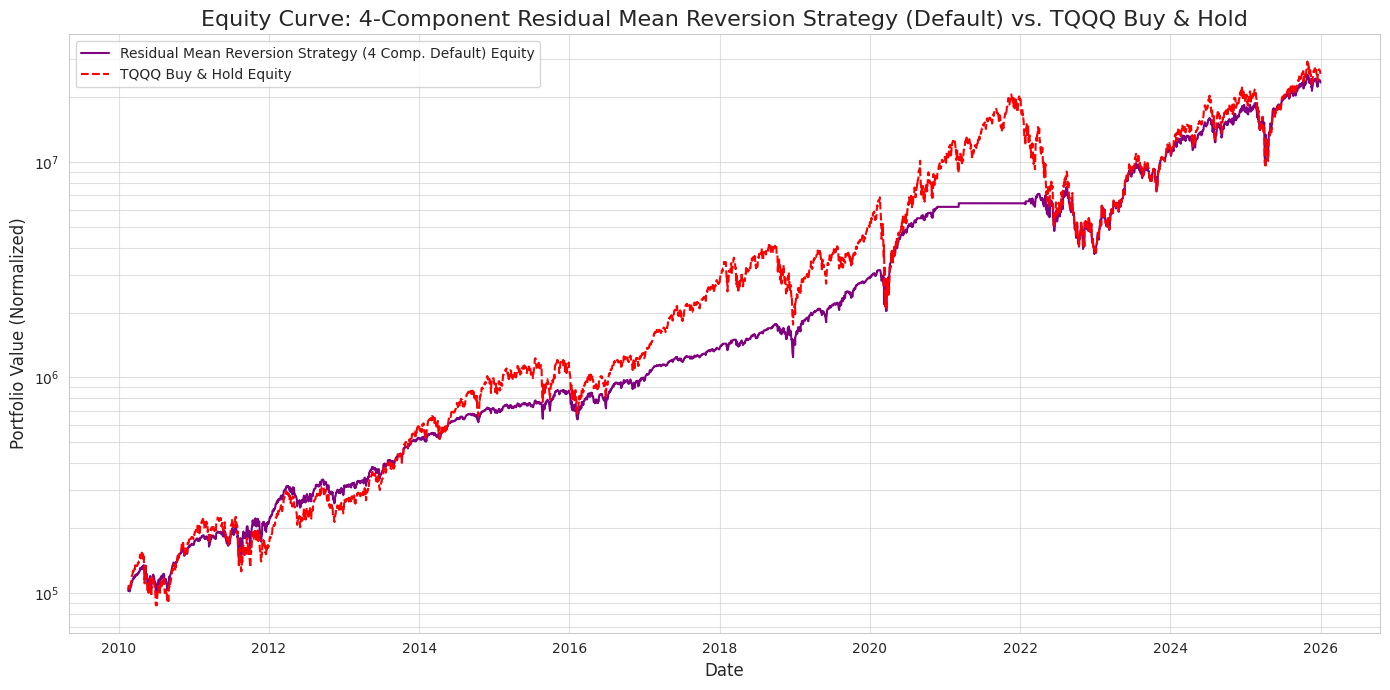

In [39]:
# Plot equity curve for Residual Mean Reversion Strategy (4 Comp. Default Allocations)
sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))

plt.plot(strategy_df.index, strategy_df['Strategy_Equity'], label='Residual Mean Reversion Strategy (4 Comp. Default) Equity', color='purple')
plt.plot(strategy_df.index, strategy_df['Benchmark_Equity'], label='TQQQ Buy & Hold Equity', color='red', linestyle='--')

plt.title('Equity Curve: 4-Component Residual Mean Reversion Strategy (Default) vs. TQQQ Buy & Hold', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value (Normalized)', fontsize=12)
plt.legend(fontsize=10)
plt.yscale('log') # Use log scale for better visualization of exponential growth
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

### Mean Reversion Strategy based on Logarithmic Trend - 5 Residuals

In [16]:
# Run the discrete GMM strategy for 5 components
initial_portfolio_value = 100000.0
gmm_5_component_results = run_discrete_gmm_strategy(regression_df, n_components=5, initial_portfolio_value=initial_portfolio_value)

# Extract results for printing
strategy_df_5_comp = gmm_5_component_results['strategy_df'] # Use a different name to avoid conflict with 4-comp strategy_df
residual_summary_5_comp = gmm_5_component_results['residual_summary']
val_strat_str_5_comp = gmm_5_component_results['val_strat_str']
val_bench_str_5_comp = gmm_5_component_results['val_bench_str']
cagr_strat_str_5_comp = gmm_5_component_results['cagr_strat_str']
cagr_bench_str_5_comp = gmm_5_component_results['cagr_bench_str']
strat_vol_5_comp = gmm_5_component_results['strat_vol']
bench_vol_5_comp = gmm_5_component_results['bench_vol']
strat_sharpe_5_comp = gmm_5_component_results['strat_sharpe']
bench_sharpe_5_comp = gmm_5_component_results['bench_sharpe']
mdd_strat_str_5_comp = gmm_5_component_results['mdd_strat_str']
mdd_bench_str_5_comp = gmm_5_component_results['mdd_bench_str']

print("\n--- DISCOVERED RESIDUAL REGIMES (5 Components) ---")
display(residual_summary_5_comp)
print(f"\n--- 5-COMPONENT GMM STRATEGY PERFORMANCE ---")
print(f"\n{'Metric':<25}{'Residual Mean Reversion':<25}{'TQQQ Buy & Hold':<20}")
print("-" * 70)
print(f"{'Ending Portfolio Value':<25}{val_strat_str_5_comp:<25}{val_bench_str_5_comp:<20}")
print(f"{'CAGR':<25}{cagr_strat_str_5_comp:<25}{cagr_bench_str_5_comp:<20}")
print(f"{'Annualized Vol':<25}{f'{strat_vol_5_comp:.2f}%':<25}{f'{bench_vol_5_comp:.2f}%':<20}")
print(f"{'Sharpe Ratio':<25}{f'{strat_sharpe_5_comp:.2f}':<25}{f'{bench_sharpe_5_comp:.2f}':<20}")
print(f"{'Max Drawdown':<25}{mdd_strat_str_5_comp:<25}{mdd_bench_str_5_comp:<20}")
print("-" * 70)


--- DISCOVERED RESIDUAL REGIMES (5 Components) ---


,min,max,mean,count,Target_Allocation
Residual_Regime,,,,,
0,-1.063691,-0.505831,-0.695550,258,1.00
1,-0.503600,-0.194630,-0.314544,885,0.75
2,-0.194052,0.095381,-0.057991,1395,0.50
3,0.096799,0.513265,0.270624,1146,0.25
4,0.514701,1.008557,0.730306,313,0.00



--- 5-COMPONENT GMM STRATEGY PERFORMANCE ---

Metric                   Residual Mean Reversion  TQQQ Buy & Hold     
----------------------------------------------------------------------
Ending Portfolio Value   $18,757,551.37           $25,543,135.53      
CAGR                     39.07%                   41.80%              
Annualized Vol           38.33%                   61.11%              
Sharpe Ratio             1.02                     0.68                
Max Drawdown             -50.89%                  -81.66%             
----------------------------------------------------------------------


### 5 Discrete Residual Mean Reversion Strategy Equity Curve

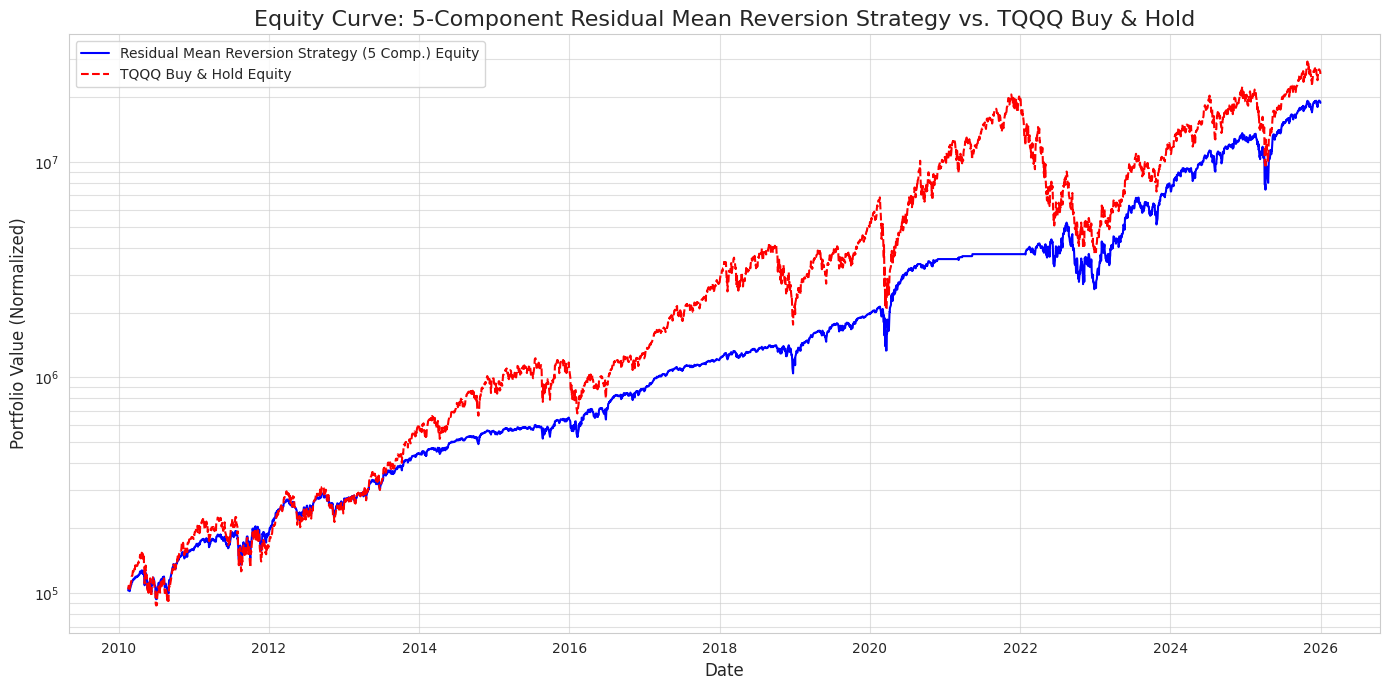

In [17]:
sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))

plt.plot(strategy_df_5_comp.index, strategy_df_5_comp['Strategy_Equity'], label='Residual Mean Reversion Strategy (5 Comp.) Equity', color='blue')
plt.plot(strategy_df_5_comp.index, strategy_df_5_comp['Benchmark_Equity'], label='TQQQ Buy & Hold Equity', color='red', linestyle='--')

plt.title('Equity Curve: 5-Component Residual Mean Reversion Strategy vs. TQQQ Buy & Hold', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value (Normalized)', fontsize=12)
plt.legend(fontsize=10)
plt.yscale('log') # Use log scale for better visualization of exponential growth
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

### Mean Reversion Strategy based on Logarithmic Trend - 6 Residuals

In [18]:
# Run the discrete GMM strategy for 6 components
initial_portfolio_value = 100000.0
gmm_6_component_results = run_discrete_gmm_strategy(regression_df, n_components=6, initial_portfolio_value=initial_portfolio_value)

# Extract results for printing
strategy_df_6_comp = gmm_6_component_results['strategy_df'] # Use a different name to avoid conflict
residual_summary_6_comp = gmm_6_component_results['residual_summary']
val_strat_str_6_comp = gmm_6_component_results['val_strat_str']
val_bench_str_6_comp = gmm_6_component_results['val_bench_str']
cagr_strat_str_6_comp = gmm_6_component_results['cagr_strat_str']
cagr_bench_str_6_comp = gmm_6_component_results['cagr_bench_str']
strat_vol_6_comp = gmm_6_component_results['strat_vol']
bench_vol_6_comp = gmm_6_component_results['bench_vol']
strat_sharpe_6_comp = gmm_6_component_results['strat_sharpe']
bench_sharpe_6_comp = gmm_6_component_results['bench_sharpe']
mdd_strat_str_6_comp = gmm_6_component_results['mdd_strat_str']
mdd_bench_str_6_comp = gmm_6_component_results['mdd_bench_str']

print("\n--- DISCOVERED RESIDUAL REGIMES (6 Components) ---")
display(residual_summary_6_comp)
print(f"\n--- 6-COMPONENT GMM STRATEGY PERFORMANCE ---")
print(f"\n{'Metric':<25}{'Residual Mean Reversion':<25}{'TQQQ Buy & Hold':<20}")
print("-" * 70)
print(f"{'Ending Portfolio Value':<25}{val_strat_str_6_comp:<25}{val_bench_str_6_comp:<20}")
print(f"{'CAGR':<25}{cagr_strat_str_6_comp:<25}{cagr_bench_str_6_comp:<20}")
print(f"{'Annualized Vol':<25}{f'{strat_vol_6_comp:.2f}%':<25}{f'{bench_vol_6_comp:.2f}%':<20}")
print(f"{'Sharpe Ratio':<25}{f'{strat_sharpe_6_comp:.2f}':<25}{f'{bench_sharpe_6_comp:.2f}':<20}")
print(f"{'Max Drawdown':<25}{mdd_strat_str_6_comp:<25}{mdd_bench_str_6_comp:<20}")
print("-" * 70)


--- DISCOVERED RESIDUAL REGIMES (6 Components) ---


,min,max,mean,count,Target_Allocation
Residual_Regime,,,,,
0,-1.063691,-0.503349,-0.694072,260,1.0
1,-0.500719,-0.217435,-0.326535,792,0.8
2,-0.217100,0.007017,-0.105188,1121,0.6
3,0.007313,0.241967,0.122999,896,0.4
4,0.242240,0.566687,0.366391,657,0.2
5,0.572452,1.008557,0.760384,271,0.0



--- 6-COMPONENT GMM STRATEGY PERFORMANCE ---

Metric                   Residual Mean Reversion  TQQQ Buy & Hold     
----------------------------------------------------------------------
Ending Portfolio Value   $21,910,457.13           $25,543,135.53      
CAGR                     40.44%                   41.80%              
Annualized Vol           40.20%                   61.11%              
Sharpe Ratio             1.01                     0.68                
Max Drawdown             -51.14%                  -81.66%             
----------------------------------------------------------------------


### 6 Discrete Residual Mean Reversion Strategy Equity Curve

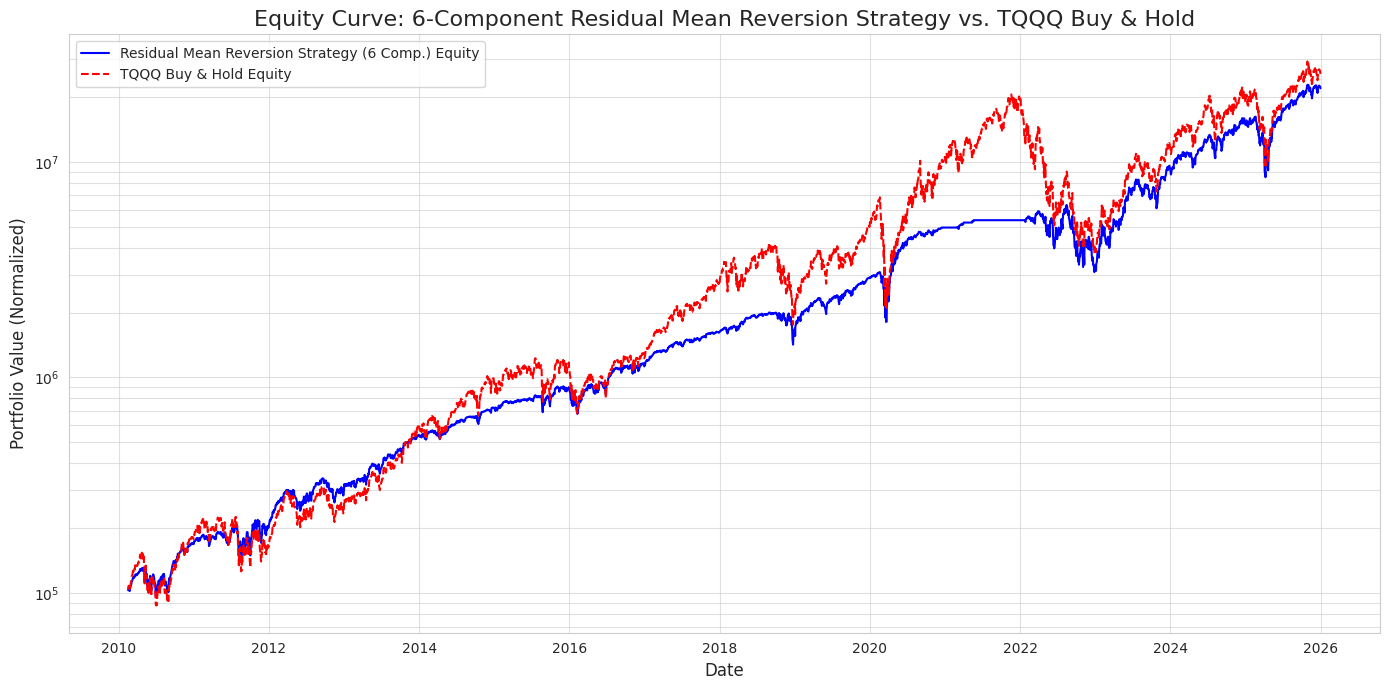

In [19]:
sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))

plt.plot(strategy_df_6_comp.index, strategy_df_6_comp['Strategy_Equity'], label='Residual Mean Reversion Strategy (6 Comp.) Equity', color='blue')
plt.plot(strategy_df_6_comp.index, strategy_df_6_comp['Benchmark_Equity'], label='TQQQ Buy & Hold Equity', color='red', linestyle='--')

plt.title('Equity Curve: 6-Component Residual Mean Reversion Strategy vs. TQQQ Buy & Hold', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value (Normalized)', fontsize=12)
plt.legend(fontsize=10)
plt.yscale('log') # Use log scale for better visualization of exponential growth
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

### Mean Reversion Strategy based on Logarithmic Trend - 7 Residuals

In [20]:
# Run the discrete GMM strategy for 7 components
initial_portfolio_value = 100000.0
gmm_7_component_results = run_discrete_gmm_strategy(regression_df, n_components=7, initial_portfolio_value=initial_portfolio_value)

# Extract results for printing
strategy_df_7_comp = gmm_7_component_results['strategy_df'] # Use a different name to avoid conflict
residual_summary_7_comp = gmm_7_component_results['residual_summary']
val_strat_str_7_comp = gmm_7_component_results['val_strat_str']
val_bench_str_7_comp = gmm_7_component_results['val_bench_str']
cagr_strat_str_7_comp = gmm_7_component_results['cagr_strat_str']
cagr_bench_str_7_comp = gmm_7_component_results['cagr_bench_str']
strat_vol_7_comp = gmm_7_component_results['strat_vol']
bench_vol_7_comp = gmm_7_component_results['bench_vol']
strat_sharpe_7_comp = gmm_7_component_results['strat_sharpe']
bench_sharpe_7_comp = gmm_7_component_results['bench_sharpe']
mdd_strat_str_7_comp = gmm_7_component_results['mdd_strat_str']
mdd_bench_str_7_comp = gmm_7_component_results['mdd_bench_str']

print("\n--- DISCOVERED RESIDUAL REGIMES (7 Components) ---")
display(residual_summary_7_comp)
print(f"\n--- 7-COMPONENT GMM STRATEGY PERFORMANCE ---")
print(f"\n{'Metric':<25}{'Residual Mean Reversion':<25}{'TQQQ Buy & Hold':<20}")
print("-" * 70)
print(f"{'Ending Portfolio Value':<25}{val_strat_str_7_comp:<25}{val_bench_str_7_comp:<20}")
print(f"{'CAGR':<25}{cagr_strat_str_7_comp:<25}{cagr_bench_str_7_comp:<20}")
print(f"{'Annualized Vol':<25}{f'{strat_vol_7_comp:.2f}%':<25}{f'{bench_vol_7_comp:.2f}%':<20}")
print(f"{'Sharpe Ratio':<25}{f'{strat_sharpe_7_comp:.2f}':<25}{f'{bench_sharpe_7_comp:.2f}':<20}")
print(f"{'Max Drawdown':<25}{mdd_strat_str_7_comp:<25}{mdd_bench_str_7_comp:<20}")
print("-" * 70)


--- DISCOVERED RESIDUAL REGIMES (7 Components) ---


,min,max,mean,count,Target_Allocation
Residual_Regime,,,,,
0,-1.063691,-0.505831,-0.695550,258,1.000000
1,-0.503600,-0.240928,-0.340133,700,0.833333
2,-0.239513,-0.060088,-0.144829,901,0.666667
3,-0.059782,0.114247,0.021053,738,0.500000
4,0.115174,0.337974,0.224285,779,0.333333
5,0.338756,0.591125,0.439864,366,0.166667
6,0.592579,1.008557,0.771730,255,0.000000



--- 7-COMPONENT GMM STRATEGY PERFORMANCE ---

Metric                   Residual Mean Reversion  TQQQ Buy & Hold     
----------------------------------------------------------------------
Ending Portfolio Value   $23,473,144.61           $25,543,135.53      
CAGR                     41.05%                   41.80%              
Annualized Vol           41.28%                   61.11%              
Sharpe Ratio             0.99                     0.68                
Max Drawdown             -52.38%                  -81.66%             
----------------------------------------------------------------------


### 7 Discrete Residual Mean Reversion Strategy Equity Curve

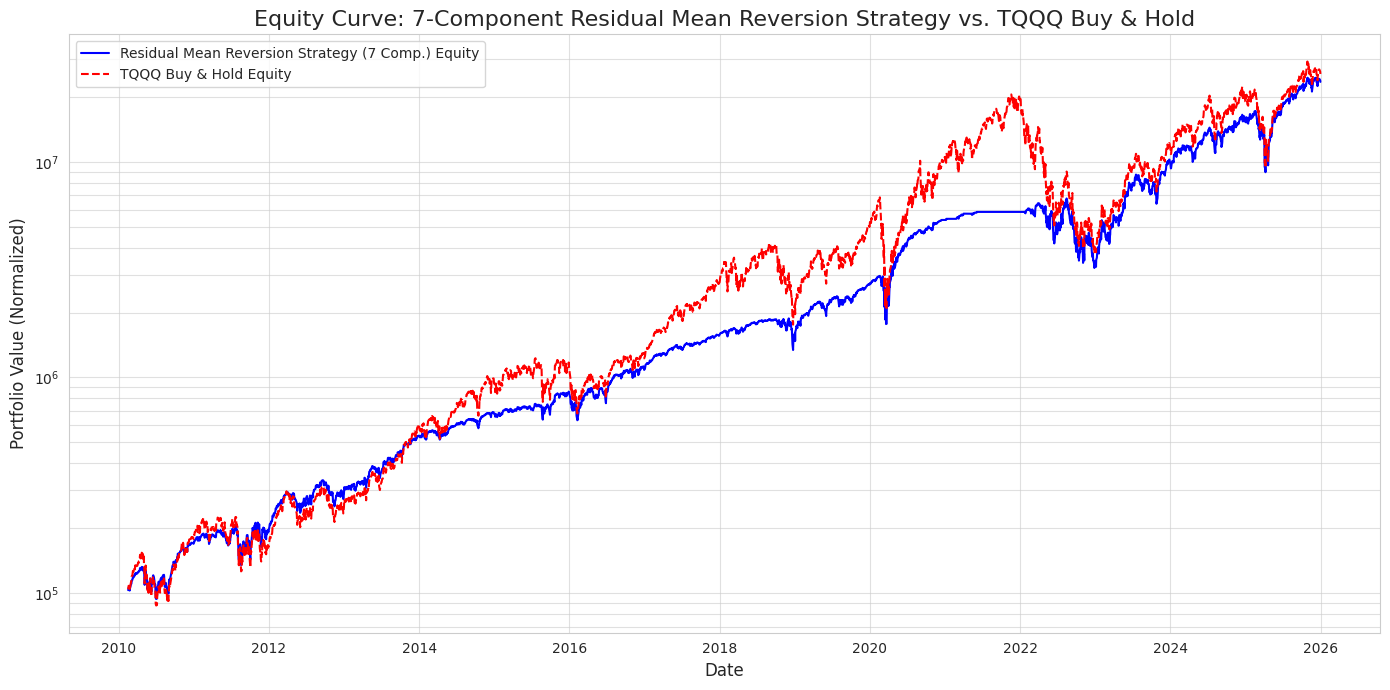

In [21]:
sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))

plt.plot(strategy_df_7_comp.index, strategy_df_7_comp['Strategy_Equity'], label='Residual Mean Reversion Strategy (7 Comp.) Equity', color='blue')
plt.plot(strategy_df_7_comp.index, strategy_df_7_comp['Benchmark_Equity'], label='TQQQ Buy & Hold Equity', color='red', linestyle='--')

plt.title('Equity Curve: 7-Component Residual Mean Reversion Strategy vs. TQQQ Buy & Hold', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value (Normalized)', fontsize=12)
plt.legend(fontsize=10)
plt.yscale('log') # Use log scale for better visualization of exponential growth
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

### Mean Reversion Strategy based on Logarithmic Trend - 8 Residuals

In [22]:
# Run the discrete GMM strategy for 8 components
initial_portfolio_value = 100000.0
gmm_8_component_results = run_discrete_gmm_strategy(regression_df, n_components=8, initial_portfolio_value=initial_portfolio_value)

# Extract results for printing
strategy_df_8_comp = gmm_8_component_results['strategy_df'] # Use a different name to avoid conflict
residual_summary_8_comp = gmm_8_component_results['residual_summary']
val_strat_str_8_comp = gmm_8_component_results['val_strat_str']
val_bench_str_8_comp = gmm_8_component_results['val_bench_str']
cagr_strat_str_8_comp = gmm_8_component_results['cagr_strat_str']
cagr_bench_str_8_comp = gmm_8_component_results['cagr_bench_str']
strat_vol_8_comp = gmm_8_component_results['strat_vol']
bench_vol_8_comp = gmm_8_component_results['bench_vol']
strat_sharpe_8_comp = gmm_8_component_results['strat_sharpe']
bench_sharpe_8_comp = gmm_8_component_results['bench_sharpe']
mdd_strat_str_8_comp = gmm_8_component_results['mdd_strat_str']
mdd_bench_str_8_comp = gmm_8_component_results['mdd_bench_str']

print("\n--- DISCOVERED RESIDUAL REGIMES (8 Components) ---")
display(residual_summary_8_comp)
print(f"\n--- 8-COMPONENT GMM STRATEGY PERFORMANCE ---")
print(f"\n{'Metric':<25}{'Residual Mean Reversion':<25}{'TQQQ Buy & Hold':<20}")
print("-" * 70)
print(f"{'Ending Portfolio Value':<25}{val_strat_str_8_comp:<25}{val_bench_str_8_comp:<20}")
print(f"{'CAGR':<25}{cagr_strat_str_8_comp:<25}{cagr_bench_str_8_comp:<20}")
print(f"{'Annualized Vol':<25}{f'{strat_vol_8_comp:.2f}%':<25}{f'{bench_vol_8_comp:.2f}%':<20}")
print(f"{'Sharpe Ratio':<25}{f'{strat_sharpe_8_comp:.2f}':<25}{f'{bench_sharpe_8_comp:.2f}':<20}")
print(f"{'Max Drawdown':<25}{mdd_strat_str_8_comp:<25}{mdd_bench_str_8_comp:<20}")
print("-" * 70)


--- DISCOVERED RESIDUAL REGIMES (8 Components) ---


,min,max,mean,count,Target_Allocation
Residual_Regime,,,,,
0,-1.063691,-0.600581,-0.753764,186,1.000000
1,-0.597025,-0.405808,-0.481973,209,0.857143
2,-0.404870,-0.210198,-0.298377,682,0.714286
3,-0.209968,-0.035923,-0.119681,921,0.571429
4,-0.034724,0.130208,0.043762,650,0.428571
5,0.131240,0.362088,0.240837,791,0.285714
6,0.362580,0.611830,0.465727,319,0.142857
7,0.614480,1.008557,0.783000,239,0.000000



--- 8-COMPONENT GMM STRATEGY PERFORMANCE ---

Metric                   Residual Mean Reversion  TQQQ Buy & Hold     
----------------------------------------------------------------------
Ending Portfolio Value   $16,169,228.63           $25,543,135.53      
CAGR                     37.77%                   41.80%              
Annualized Vol           38.27%                   61.11%              
Sharpe Ratio             0.99                     0.68                
Max Drawdown             -49.26%                  -81.66%             
----------------------------------------------------------------------


### 8 Discrete Residual Mean Reversion Strategy Equity Curve

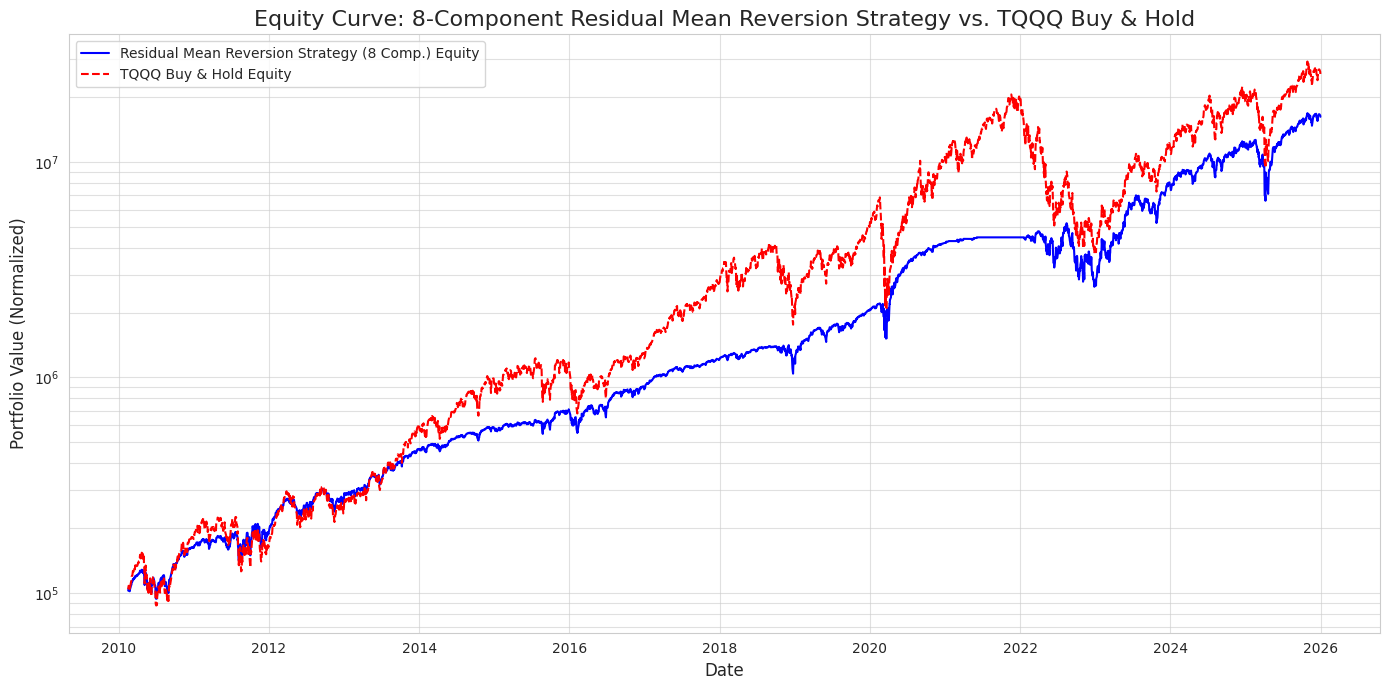

In [23]:
sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))

plt.plot(strategy_df_8_comp.index, strategy_df_8_comp['Strategy_Equity'], label='Residual Mean Reversion Strategy (8 Comp.) Equity', color='blue')
plt.plot(strategy_df_8_comp.index, strategy_df_8_comp['Benchmark_Equity'], label='TQQQ Buy & Hold Equity', color='red', linestyle='--')

plt.title('Equity Curve: 8-Component Residual Mean Reversion Strategy vs. TQQQ Buy & Hold', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value (Normalized)', fontsize=12)
plt.legend(fontsize=10)
plt.yscale('log') # Use log scale for better visualization of exponential growth
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

### Mean Reversion Strategy based on Logarithmic Trend - 9 Residuals

### Backtesting the 9 Discrete Residual Mean Reversion Strategy

In [30]:
# Run the discrete GMM strategy for 9 components
initial_portfolio_value = 100000.0
gmm_9_component_results = run_discrete_gmm_strategy(regression_df, n_components=9, initial_portfolio_value=initial_portfolio_value)

# Extract results for printing
strategy_df_9_comp = gmm_9_component_results['strategy_df']
residual_summary_9_comp = gmm_9_component_results['residual_summary']
val_strat_str_9_comp = gmm_9_component_results['val_strat_str']
val_bench_str_9_comp = gmm_9_component_results['val_bench_str']
cagr_strat_str_9_comp = gmm_9_component_results['cagr_strat_str']
cagr_bench_str_9_comp = gmm_9_component_results['cagr_bench_str']
strat_vol_9_comp = gmm_9_component_results['strat_vol']
bench_vol_9_comp = gmm_9_component_results['bench_vol']
strat_sharpe_9_comp = gmm_9_component_results['strat_sharpe']
bench_sharpe_9_comp = gmm_9_component_results['bench_sharpe']
mdd_strat_str_9_comp = gmm_9_component_results['mdd_strat_str']
mdd_bench_str_9_comp = gmm_9_component_results['mdd_bench_str']

print("\n--- DISCOVERED RESIDUAL REGIMES (9 Components) ---")
display(residual_summary_9_comp)
print(f"\n--- 9-COMPONENT GMM STRATEGY PERFORMANCE ---")
print(f"\n{'Metric':<25}{'Residual Mean Reversion':<25}{'TQQQ Buy & Hold':<20}")
print("-" * 70)
print(f"{'Ending Portfolio Value':<25}{val_strat_str_9_comp:<25}{val_bench_str_9_comp:<20}")
print(f"{'CAGR':<25}{cagr_strat_str_9_comp:<25}{cagr_bench_str_9_comp:<20}")
print(f"{'Annualized Vol':<25}{f'{strat_vol_9_comp:.2f}%':<25}{f'{bench_vol_9_comp:.2f}%':<20}")
print(f"{'Sharpe Ratio':<25}{f'{strat_sharpe_9_comp:.2f}':<25}{f'{bench_sharpe_9_comp:.2f}':<20}")
print(f"{'Max Drawdown':<25}{mdd_strat_str_9_comp:<25}{mdd_bench_str_9_comp:<20}")
print("-" * 70)


--- DISCOVERED RESIDUAL REGIMES (9 Components) ---


,min,max,mean,count,Target_Allocation
Residual_Regime,,,,,
0,-1.063691,-0.600581,-0.753764,186,1.000
1,-0.597025,-0.410532,-0.484531,202,0.875
2,-0.409658,-0.219718,-0.303353,659,0.750
3,-0.218637,-0.070344,-0.139850,765,0.625
4,-0.069954,0.071624,-0.001705,638,0.500
5,0.071847,0.218924,0.147792,525,0.375
6,0.219154,0.380524,0.291119,493,0.250
7,0.381788,0.630105,0.483248,307,0.125
8,0.632099,1.008557,0.795448,222,0.000



--- 9-COMPONENT GMM STRATEGY PERFORMANCE ---

Metric                   Residual Mean Reversion  TQQQ Buy & Hold     
----------------------------------------------------------------------
Ending Portfolio Value   $18,056,797.54           $25,543,135.53      
CAGR                     38.73%                   41.80%              
Annualized Vol           39.46%                   61.11%              
Sharpe Ratio             0.98                     0.68                
Max Drawdown             -50.42%                  -81.66%             
----------------------------------------------------------------------


### 9 Discrete Residual Mean Reversion Strategy Equity Curve

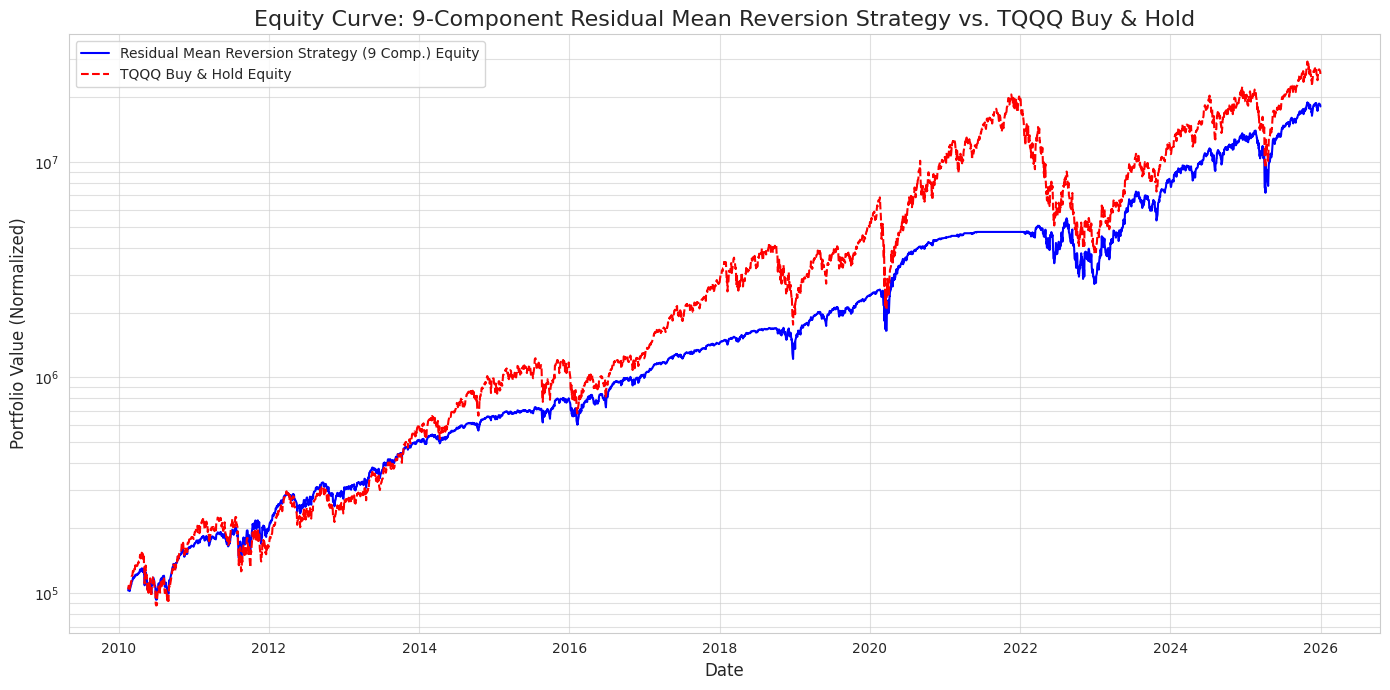

In [31]:
sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))

plt.plot(strategy_df_9_comp.index, strategy_df_9_comp['Strategy_Equity'], label='Residual Mean Reversion Strategy (9 Comp.) Equity', color='blue')
plt.plot(strategy_df_9_comp.index, strategy_df_9_comp['Benchmark_Equity'], label='TQQQ Buy & Hold Equity', color='red', linestyle='--')

plt.title('Equity Curve: 9-Component Residual Mean Reversion Strategy vs. TQQQ Buy & Hold', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value (Normalized)', fontsize=12)
plt.legend(fontsize=10)
plt.yscale('log') # Use log scale for better visualization of exponential growth
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

### Mean Reversion Strategy based on Logarithmic Trend - 10 Residuals

### Backtesting the 10 Discrete Residual Mean Reversion Strategy

In [36]:
# Run the discrete GMM strategy for 10 components
initial_portfolio_value = 100000.0
gmm_10_component_results = run_discrete_gmm_strategy(regression_df, n_components=10, initial_portfolio_value=initial_portfolio_value)

# Extract results for printing
strategy_df_10_comp = gmm_10_component_results['strategy_df']
residual_summary_10_comp = gmm_10_component_results['residual_summary']
val_strat_str_10_comp = gmm_10_component_results['val_strat_str']
val_bench_str_10_comp = gmm_10_component_results['val_bench_str']
cagr_strat_str_10_comp = gmm_10_component_results['cagr_strat_str']
cagr_bench_str_10_comp = gmm_10_component_results['cagr_bench_str']
strat_vol_10_comp = gmm_10_component_results['strat_vol']
bench_vol_10_comp = gmm_10_component_results['bench_vol']
strat_sharpe_10_comp = gmm_10_component_results['strat_sharpe']
bench_sharpe_10_comp = gmm_10_component_results['bench_sharpe']
mdd_strat_str_10_comp = gmm_10_component_results['mdd_strat_str']
mdd_bench_str_10_comp = gmm_10_component_results['mdd_bench_str']

print("\n--- DISCOVERED RESIDUAL REGIMES (10 Components) ---")
display(residual_summary_10_comp)
print(f"\n--- 10-COMPONENT GMM STRATEGY PERFORMANCE ---")
print(f"\n{'Metric':<25}{'Residual Mean Reversion':<25}{'TQQQ Buy & Hold':<20}")
print("-" * 70)
print(f"{'Ending Portfolio Value':<25}{val_strat_str_10_comp:<25}{val_bench_str_10_comp:<20}")
print(f"{'CAGR':<25}{cagr_strat_str_10_comp:<25}{cagr_bench_str_10_comp:<20}")
print(f"{'Annualized Vol':<25}{f'{strat_vol_10_comp:.2f}%':<25}{f'{bench_vol_10_comp:.2f}%':<20}")
print(f"{'Sharpe Ratio':<25}{f'{strat_sharpe_10_comp:.2f}':<25}{f'{bench_sharpe_10_comp:.2f}':<20}")
print(f"{'Max Drawdown':<25}{mdd_strat_str_10_comp:<25}{mdd_bench_str_10_comp:<20}")
print("-" * 70)


--- DISCOVERED RESIDUAL REGIMES (10 Components) ---


,min,max,mean,count,Target_Allocation
Residual_Regime,,,,,
0,-1.063691,-0.781597,-0.871608,70,1.000000
1,-0.776581,-0.562017,-0.666787,137,0.888889
2,-0.558649,-0.382920,-0.456470,232,0.777778
3,-0.381934,-0.210412,-0.291918,637,0.666667
4,-0.210198,-0.065332,-0.134901,758,0.555556
5,-0.064632,0.082676,0.005800,660,0.444444
6,0.083127,0.224645,0.157044,502,0.333333
7,0.224960,0.381788,0.294380,473,0.222222
8,0.384647,0.630105,0.483579,306,0.111111



--- 10-COMPONENT GMM STRATEGY PERFORMANCE ---

Metric                   Residual Mean Reversion  TQQQ Buy & Hold     
----------------------------------------------------------------------
Ending Portfolio Value   $15,007,400.07           $25,543,135.53      
CAGR                     37.13%                   41.80%              
Annualized Vol           36.10%                   61.11%              
Sharpe Ratio             1.03                     0.68                
Max Drawdown             -44.59%                  -81.66%             
----------------------------------------------------------------------


### 10 Discrete Residual Mean Reversion Strategy Equity Curve

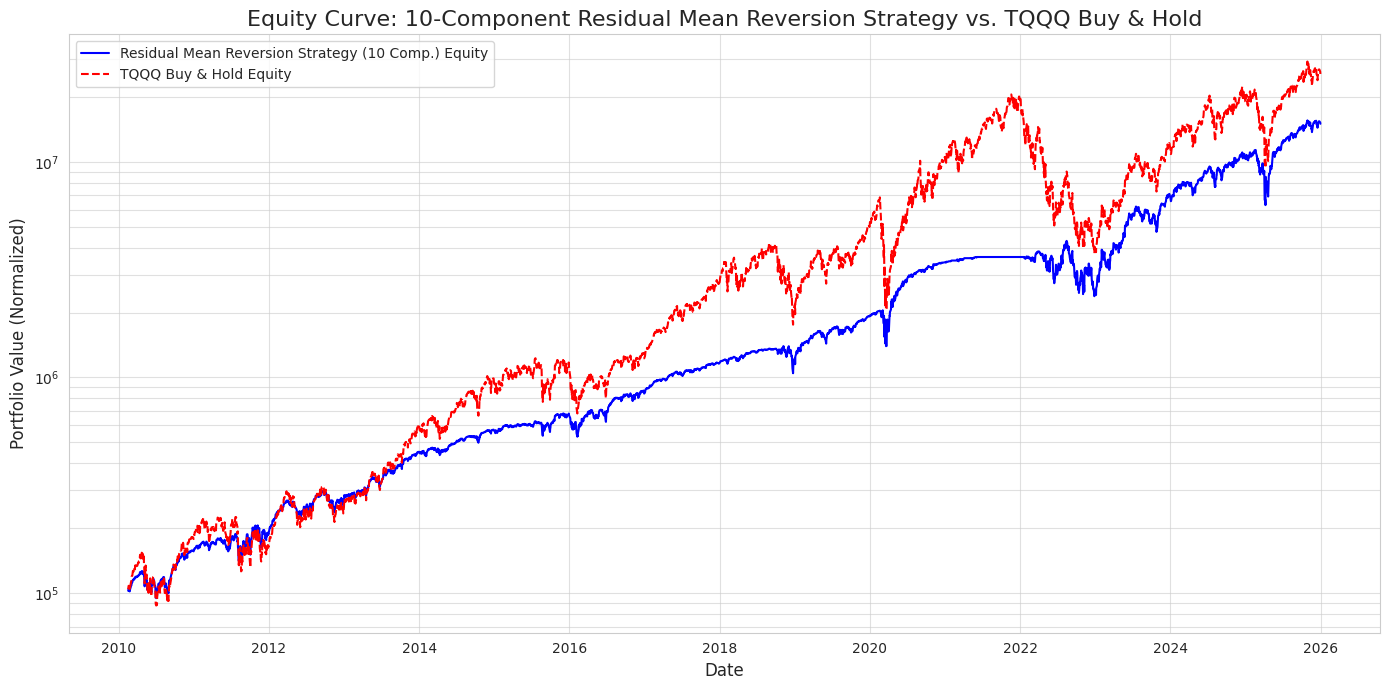

In [37]:
sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))

plt.plot(strategy_df_10_comp.index, strategy_df_10_comp['Strategy_Equity'], label='Residual Mean Reversion Strategy (10 Comp.) Equity', color='blue')
plt.plot(strategy_df_10_comp.index, strategy_df_10_comp['Benchmark_Equity'], label='TQQQ Buy & Hold Equity', color='red', linestyle='--')

plt.title('Equity Curve: 10-Component Residual Mean Reversion Strategy vs. TQQQ Buy & Hold', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value (Normalized)', fontsize=12)
plt.legend(fontsize=10)
plt.yscale('log') # Use log scale for better visualization of exponential growth
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

### Mean Reversion Strategy based on Logarithmic Trend - 10 Residuals

### Backtesting the 10 Discrete Residual Mean Reversion Strategy

In [32]:
# Run the discrete GMM strategy for 10 components
initial_portfolio_value = 100000.0
gmm_10_component_results = run_discrete_gmm_strategy(regression_df, n_components=10, initial_portfolio_value=initial_portfolio_value)

# Extract results for printing
strategy_df_10_comp = gmm_10_component_results['strategy_df']
residual_summary_10_comp = gmm_10_component_results['residual_summary']
val_strat_str_10_comp = gmm_10_component_results['val_strat_str']
val_bench_str_10_comp = gmm_10_component_results['val_bench_str']
cagr_strat_str_10_comp = gmm_10_component_results['cagr_strat_str']
cagr_bench_str_10_comp = gmm_10_component_results['cagr_bench_str']
strat_vol_10_comp = gmm_10_component_results['strat_vol']
bench_vol_10_comp = gmm_10_component_results['bench_vol']
strat_sharpe_10_comp = gmm_10_component_results['strat_sharpe']
bench_sharpe_10_comp = gmm_10_component_results['bench_sharpe']
mdd_strat_str_10_comp = gmm_10_component_results['mdd_strat_str']
mdd_bench_str_10_comp = gmm_10_component_results['mdd_bench_str']

print("\n--- DISCOVERED RESIDUAL REGIMES (10 Components) ---")
display(residual_summary_10_comp)
print(f"\n--- 10-COMPONENT GMM STRATEGY PERFORMANCE ---")
print(f"\n{'Metric':<25}{'Residual Mean Reversion':<25}{'TQQQ Buy & Hold':<20}")
print("-" * 70)
print(f"{'Ending Portfolio Value':<25}{val_strat_str_10_comp:<25}{val_bench_str_10_comp:<20}")
print(f"{'CAGR':<25}{cagr_strat_str_10_comp:<25}{cagr_bench_str_10_comp:<20}")
print(f"{'Annualized Vol':<25}{f'{strat_vol_10_comp:.2f}%':<25}{f'{bench_vol_10_comp:.2f}%':<20}")
print(f"{'Sharpe Ratio':<25}{f'{strat_sharpe_10_comp:.2f}':<25}{f'{bench_sharpe_10_comp:.2f}':<20}")
print(f"{'Max Drawdown':<25}{mdd_strat_str_10_comp:<25}{mdd_bench_str_10_comp:<20}")
print("-" * 70)


--- DISCOVERED RESIDUAL REGIMES (10 Components) ---


,min,max,mean,count,Target_Allocation
Residual_Regime,,,,,
0,-1.063691,-0.781597,-0.871608,70,1.000000
1,-0.776581,-0.562017,-0.666787,137,0.888889
2,-0.558649,-0.382920,-0.456470,232,0.777778
3,-0.381934,-0.210412,-0.291918,637,0.666667
4,-0.210198,-0.065332,-0.134901,758,0.555556
5,-0.064632,0.082676,0.005800,660,0.444444
6,0.083127,0.224645,0.157044,502,0.333333
7,0.224960,0.381788,0.294380,473,0.222222
8,0.384647,0.630105,0.483579,306,0.111111



--- 10-COMPONENT GMM STRATEGY PERFORMANCE ---

Metric                   Residual Mean Reversion  TQQQ Buy & Hold     
----------------------------------------------------------------------
Ending Portfolio Value   $15,007,400.07           $25,543,135.53      
CAGR                     37.13%                   41.80%              
Annualized Vol           36.10%                   61.11%              
Sharpe Ratio             1.03                     0.68                
Max Drawdown             -44.59%                  -81.66%             
----------------------------------------------------------------------


### 10 Discrete Residual Mean Reversion Strategy Equity Curve

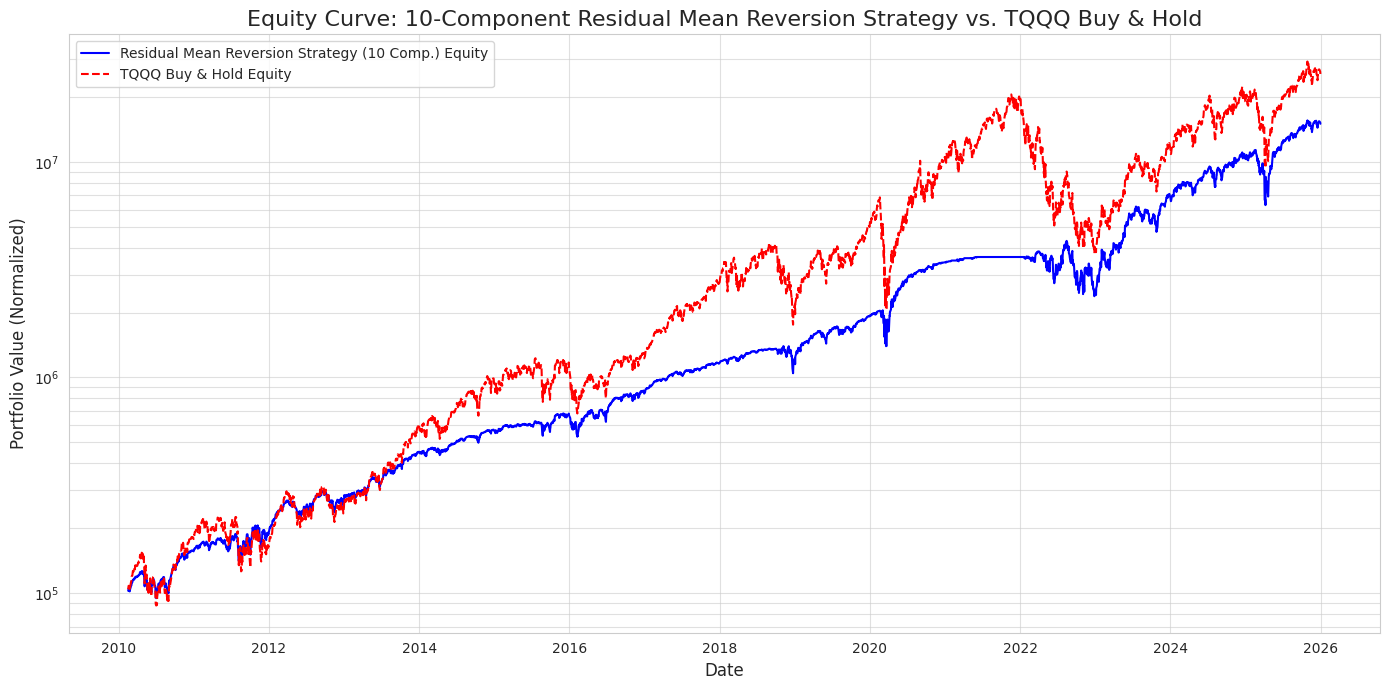

In [33]:
sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))

plt.plot(strategy_df_10_comp.index, strategy_df_10_comp['Strategy_Equity'], label='Residual Mean Reversion Strategy (10 Comp.) Equity', color='blue')
plt.plot(strategy_df_10_comp.index, strategy_df_10_comp['Benchmark_Equity'], label='TQQQ Buy & Hold Equity', color='red', linestyle='--')

plt.title('Equity Curve: 10-Component Residual Mean Reversion Strategy vs. TQQQ Buy & Hold', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value (Normalized)', fontsize=12)
plt.legend(fontsize=10)
plt.yscale('log') # Use log scale for better visualization of exponential growth
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

In [34]:
# Run the discrete GMM strategy for 10 components
initial_portfolio_value = 100000.0
gmm_10_component_results = run_discrete_gmm_strategy(regression_df, n_components=10, initial_portfolio_value=initial_portfolio_value)

# Extract results for printing
strategy_df_10_comp = gmm_10_component_results['strategy_df']
residual_summary_10_comp = gmm_10_component_results['residual_summary']
val_strat_str_10_comp = gmm_10_component_results['val_strat_str']
val_bench_str_10_comp = gmm_10_component_results['val_bench_str']
cagr_strat_str_10_comp = gmm_10_component_results['cagr_strat_str']
cagr_bench_str_10_comp = gmm_10_component_results['cagr_bench_str']
strat_vol_10_comp = gmm_10_component_results['strat_vol']
bench_vol_10_comp = gmm_10_component_results['bench_vol']
strat_sharpe_10_comp = gmm_10_component_results['strat_sharpe']
bench_sharpe_10_comp = gmm_10_component_results['bench_sharpe']
mdd_strat_str_10_comp = gmm_10_component_results['mdd_strat_str']
mdd_bench_str_10_comp = gmm_10_component_results['mdd_bench_str']

print("\n--- DISCOVERED RESIDUAL REGIMES (10 Components) ---")
display(residual_summary_10_comp)
print(f"\n--- 10-COMPONENT GMM STRATEGY PERFORMANCE ---")
print(f"\n{'Metric':<25}{'Residual Mean Reversion':<25}{'TQQQ Buy & Hold':<20}")
print("-" * 70)
print(f"{'Ending Portfolio Value':<25}{val_strat_str_10_comp:<25}{val_bench_str_10_comp:<20}")
print(f"{'CAGR':<25}{cagr_strat_str_10_comp:<25}{cagr_bench_str_10_comp:<20}")
print(f"{'Annualized Vol':<25}{f'{strat_vol_10_comp:.2f}%':<25}{f'{bench_vol_10_comp:.2f}%':<20}")
print(f"{'Sharpe Ratio':<25}{f'{strat_sharpe_10_comp:.2f}':<25}{f'{bench_sharpe_10_comp:.2f}':<20}")
print(f"{'Max Drawdown':<25}{mdd_strat_str_10_comp:<25}{mdd_bench_str_10_comp:<20}")
print("-" * 70)


--- DISCOVERED RESIDUAL REGIMES (10 Components) ---


,min,max,mean,count,Target_Allocation
Residual_Regime,,,,,
0,-1.063691,-0.781597,-0.871608,70,1.000000
1,-0.776581,-0.562017,-0.666787,137,0.888889
2,-0.558649,-0.382920,-0.456470,232,0.777778
3,-0.381934,-0.210412,-0.291918,637,0.666667
4,-0.210198,-0.065332,-0.134901,758,0.555556
5,-0.064632,0.082676,0.005800,660,0.444444
6,0.083127,0.224645,0.157044,502,0.333333
7,0.224960,0.381788,0.294380,473,0.222222
8,0.384647,0.630105,0.483579,306,0.111111



--- 10-COMPONENT GMM STRATEGY PERFORMANCE ---

Metric                   Residual Mean Reversion  TQQQ Buy & Hold     
----------------------------------------------------------------------
Ending Portfolio Value   $15,007,400.07           $25,543,135.53      
CAGR                     37.13%                   41.80%              
Annualized Vol           36.10%                   61.11%              
Sharpe Ratio             1.03                     0.68                
Max Drawdown             -44.59%                  -81.66%             
----------------------------------------------------------------------


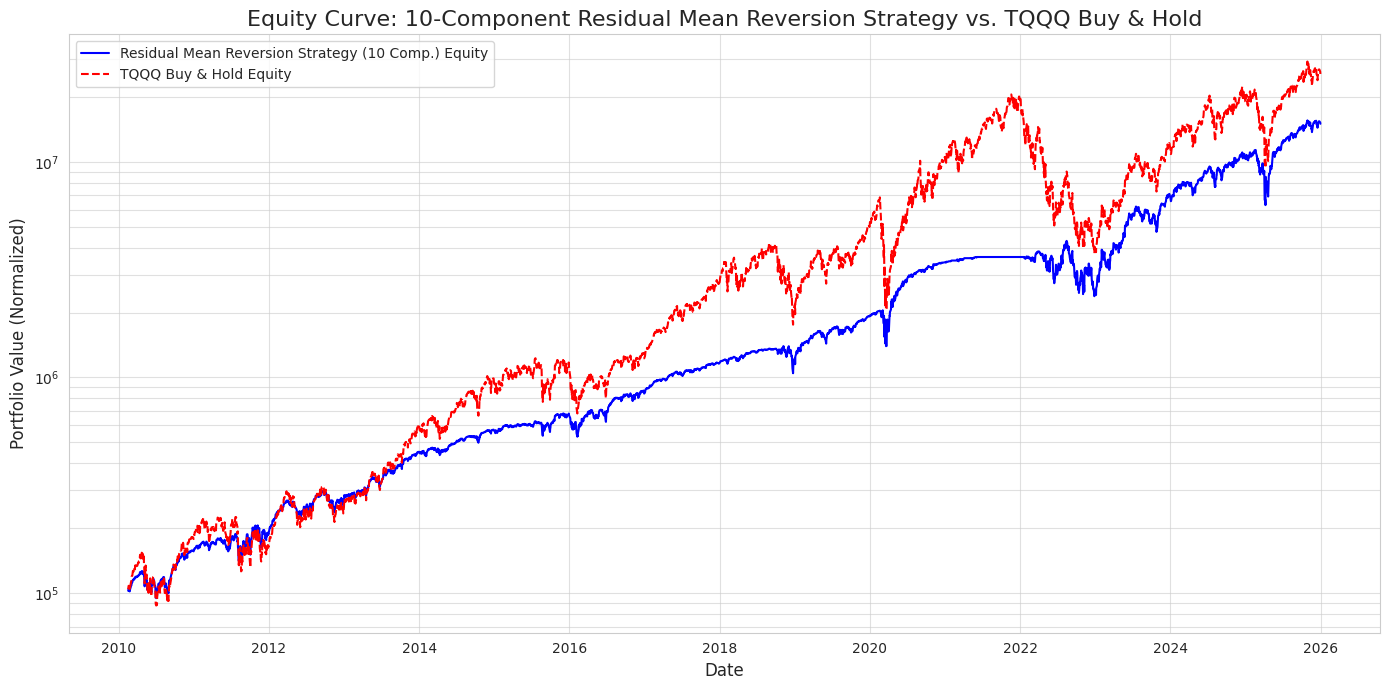

In [35]:
sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))

plt.plot(strategy_df_10_comp.index, strategy_df_10_comp['Strategy_Equity'], label='Residual Mean Reversion Strategy (10 Comp.) Equity', color='blue')
plt.plot(strategy_df_10_comp.index, strategy_df_10_comp['Benchmark_Equity'], label='TQQQ Buy & Hold Equity', color='red', linestyle='--')

plt.title('Equity Curve: 10-Component Residual Mean Reversion Strategy vs. TQQQ Buy & Hold', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value (Normalized)', fontsize=12)
plt.legend(fontsize=10)
plt.yscale('log') # Use log scale for better visualization of exponential growth
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()